In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('data_breast_cancer.csv')
df = df.drop(columns=['Unnamed: 32'], errors='ignore')
print(f"Dataset successfully loaded! Shape: {df.shape}")



Dataset successfully loaded! Shape: (569, 32)


In [4]:
#first question (display few rows from dataset)
print("--- First 5 Rows of the Breast Cancer Dataset ---")
display(df.head())

print("\n--- Last 5 Rows of the Breast Cancer Dataset ---")
display(df.tail())





--- First 5 Rows of the Breast Cancer Dataset ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Last 5 Rows of the Breast Cancer Dataset ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
#second question (identity data types of each column)#
print("--- Column Data Types and Overview ---")
df.info()


In [5]:
#checking for the missing value q.4#
print("--- Missing Values Count Per Column ---")
missing_values = df.isnull().sum()

# Display columns that have missing values
display(missing_values[missing_values > 0])

print("\n--- Percentage of Missing Values ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
display(missing_percentage[missing_percentage > 0])

--- Missing Values Count Per Column ---


Series([], dtype: int64)


--- Percentage of Missing Values ---


Series([], dtype: float64)

In [6]:
#checking for duplicate values and delete if any remaining #
print("--- Duplicate Rows Check ---")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")



--- Duplicate Rows Check ---
Number of duplicate rows: 0
No duplicate rows found.


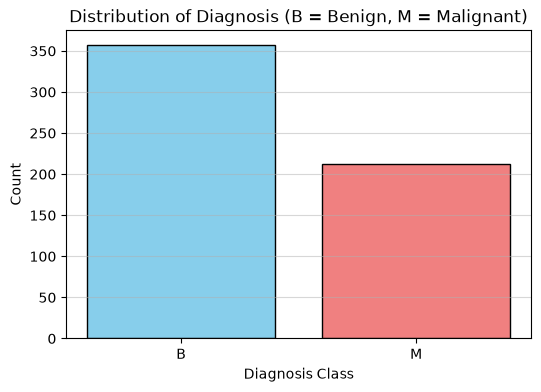

--- Visualizing Distributions of 'Mean' Features ---


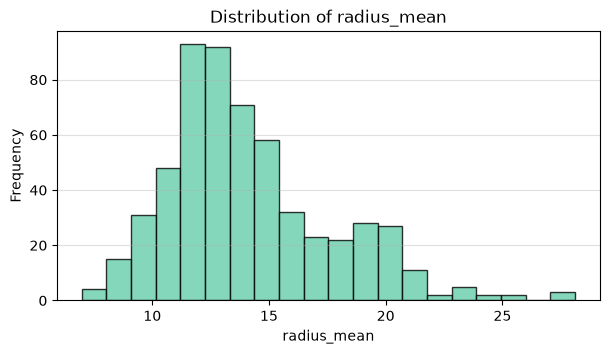

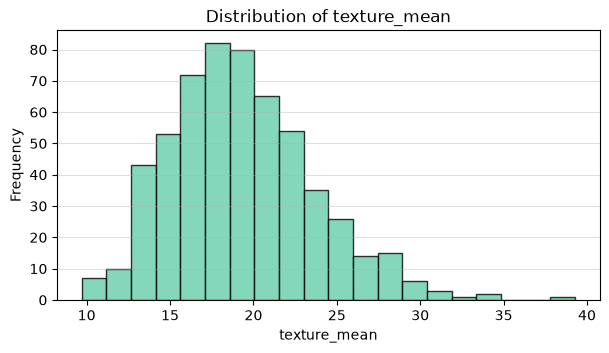

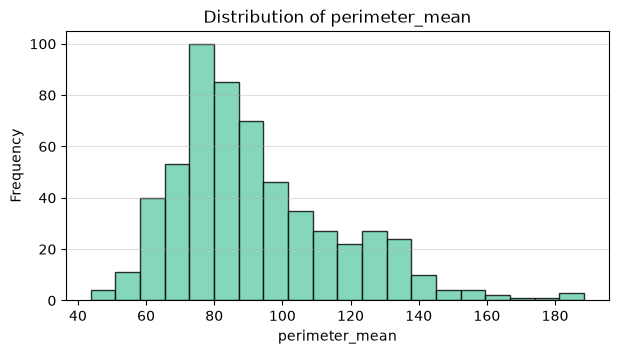

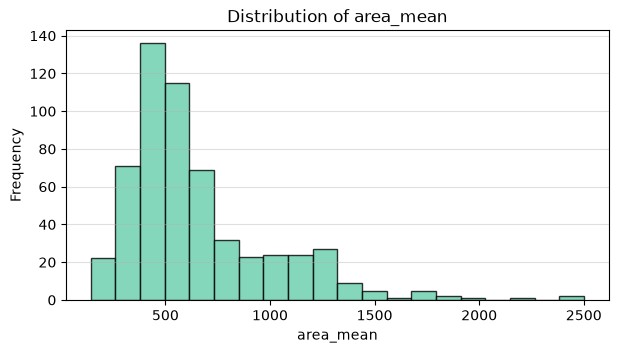

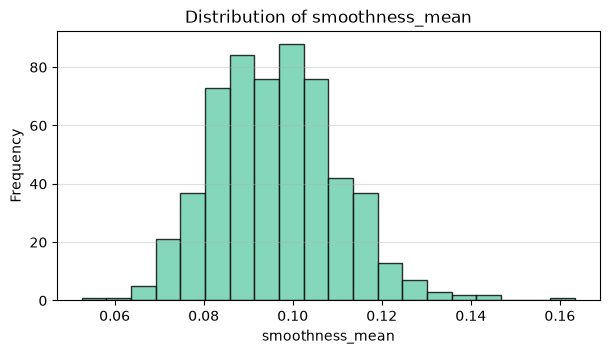

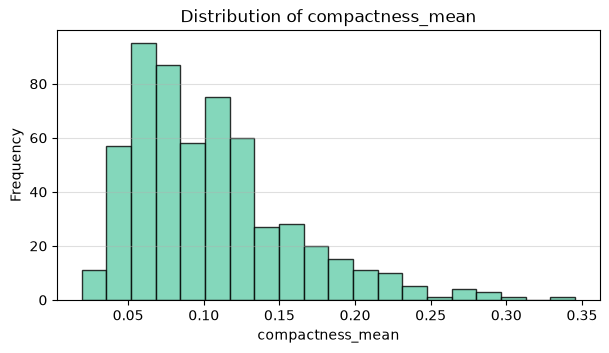

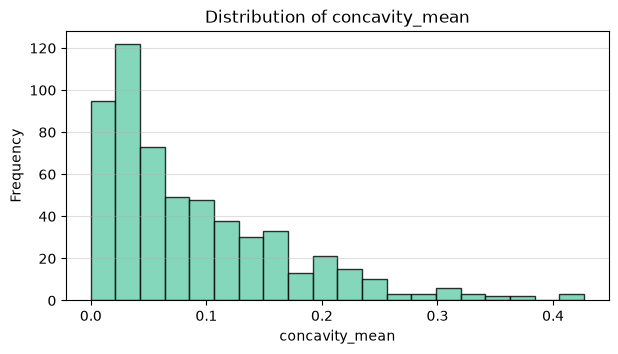

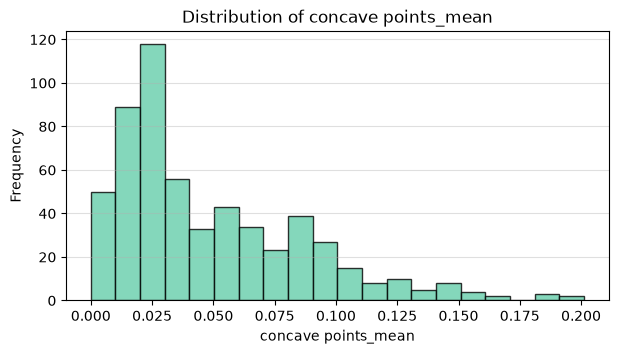

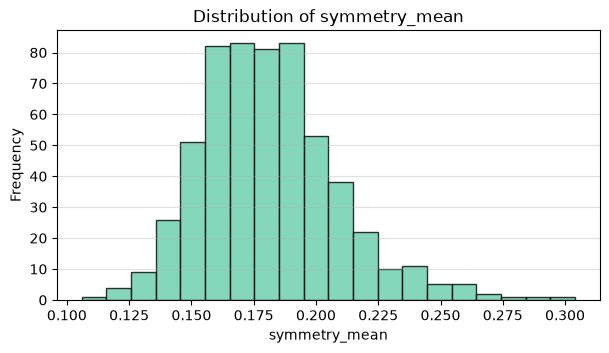

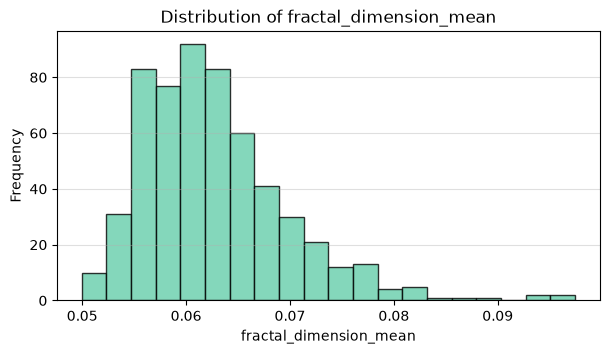

In [7]:
#create histograms and bar charts for distribution #

cols_to_plot = [col for col in df.columns if col not in ['id', 'Unnamed: 32']]

# 1. Categorical Distribution: 'diagnosis' column (M = Malignant, B = Benign)
plt.figure(figsize=(6, 4))
diagnosis_counts = df['diagnosis'].value_counts()
plt.bar(diagnosis_counts.index, diagnosis_counts.values, color=['skyblue', 'lightcoral'], edgecolor='black')
plt.title('Distribution of Diagnosis (B = Benign, M = Malignant)')
plt.xlabel('Diagnosis Class')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.show()

# 2. Numerical Distributions: Plotting the main '_mean' feature columns
mean_features = [col for col in cols_to_plot if col.endswith('_mean')]

print("--- Visualizing Distributions of 'Mean' Features ---")
for col in mean_features:
    plt.figure(figsize=(7, 3.5))
    plt.hist(df[col].dropna(), bins=20, color='mediumaquamarine', edgecolor='black', alpha=0.8)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.4)
    plt.show()






--- Exploring Relationships via Scatter Plots ---


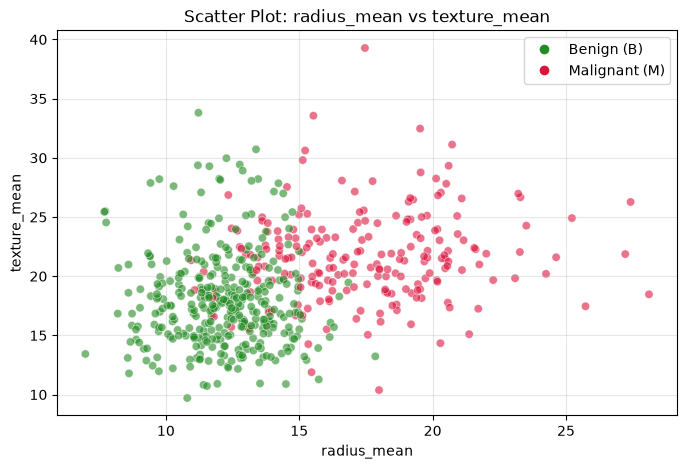

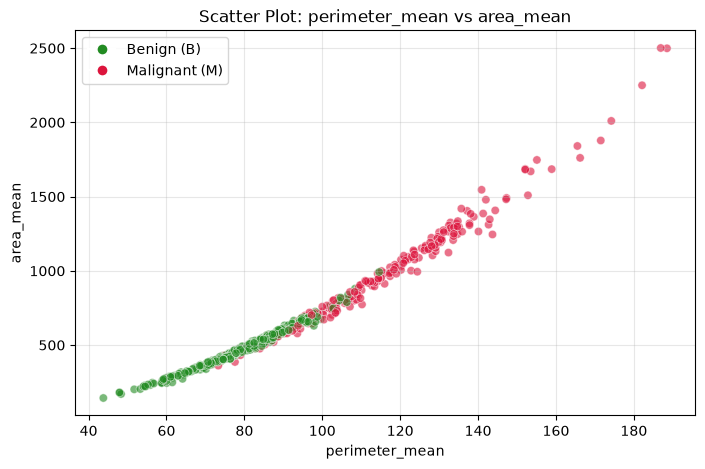

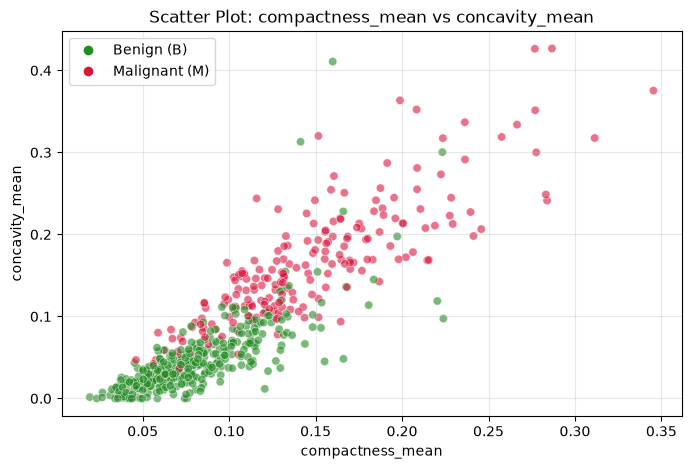

In [8]:
#question 7 : generate the scatter plot #
print("--- Exploring Relationships via Scatter Plots ---")

# Define pairs of features that typically correlate strongly with each other
scatter_pairs = [
    ('radius_mean', 'texture_mean'),
    ('perimeter_mean', 'area_mean'),
    ('compactness_mean', 'concavity_mean')
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(8, 5))
    
    # Map colors based on diagnosis: Benign (B) as green, Malignant (M) as red
    colors = df['diagnosis'].map({'B': 'forestgreen', 'M': 'crimson'})
    
    plt.scatter(df[x_col], df[y_col], c=colors, alpha=0.6, edgecolor='white', linewidths=0.5)
    plt.title(f'Scatter Plot: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    
    # Custom legend for diagnosis
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Benign (B)', markerfacecolor='forestgreen', markersize=8),
                       Line2D([0], [0], marker='o', color='w', label='Malignant (M)', markerfacecolor='crimson', markersize=8)]
    plt.legend(handles=legend_elements)
    
    plt.grid(True, alpha=0.3)
    plt.show()




--- Correlation Matrix Heatmap ---


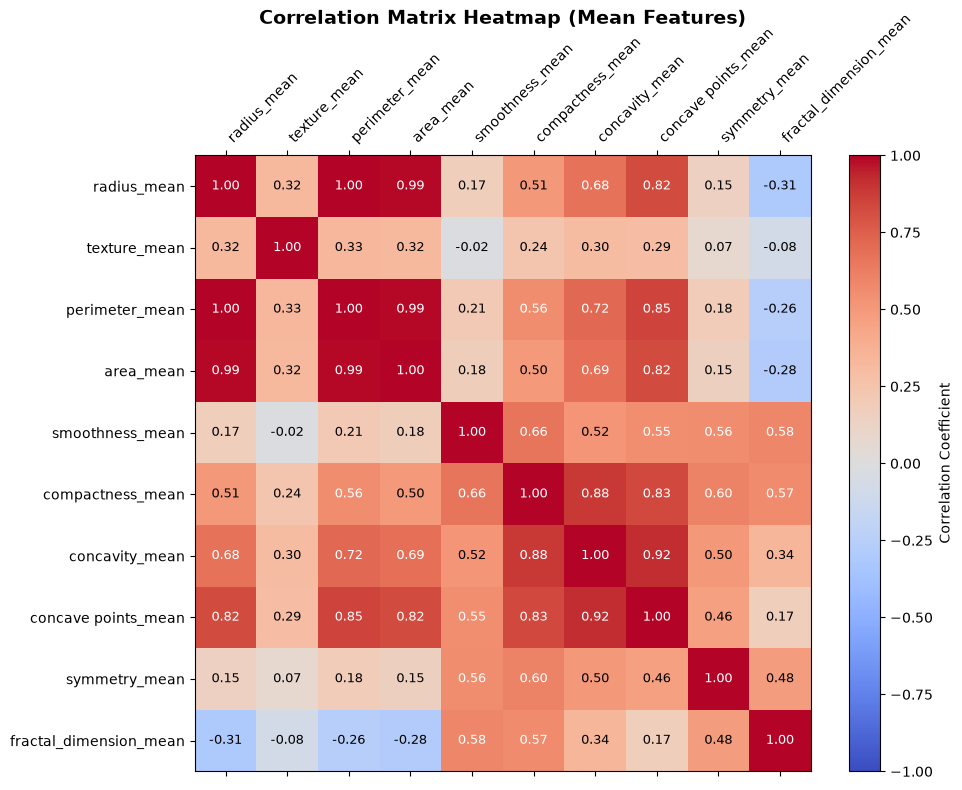

In [9]:
#question 8 : generate heatmap #
print("--- Correlation Matrix Heatmap ---")

# Calculate correlation matrix only for the main '_mean' numerical features to fit nicely on screen
mean_features = [col for col in df.columns if col.endswith('_mean')]
corr_matrix = df[mean_features].corr()

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, label='Correlation Coefficient')

# Set labels and rotation
ticks = np.arange(0, len(corr_matrix.columns), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)

# Loop to annotate values inside each cell
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        # Dynamically change text color to black/white for text contrast
        text_color = "white" if abs(val) > 0.55 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=9)

plt.title('Correlation Matrix Heatmap (Mean Features)', y=1.2, fontsize=14, weight='bold')
plt.show()